# Chunker and embedding-model comparison

Compare a chunker, embedding model, and chunk configuration on cleaned WHO PDFs and WHO web fact sheets before building the vector store. Each run measures sizes with its selected embedding model tokenizer.

In [1]:
from pathlib import Path
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from langchain_core.documents import Document

ROOT = Path.cwd()
if not (ROOT / 'app').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f'Repository root: {ROOT}')

Repository root: /Users/suzannezhen/DEV/clinical-rag-assistant


## 1. Load and clean WHO PDFs and web fact sheets

Use the switches below to include PDFs, web pages, or both. Keep the web sample small while iterating because those pages are fetched live.

In [2]:
from app.data_loading.pdf_loader import load_pdfs_from_folder
from app.data_loading.web_loader import load_who_fact_sheets
from app.data_processing.cleaning import clean_documents

INCLUDE_PDFS = True
INCLUDE_WEB_DOCS = True
MAX_PDF_PAGES = None   # e.g. 10 for a quick PDF-only iteration
MAX_WEB_DOCS = 10      # keep this small while iterating, pages are fetched live
MAX_ANALYSIS_DOCS = None

pdf_docs = []
web_docs = []

if INCLUDE_PDFS:
    pdf_docs = load_pdfs_from_folder(
        folder=str(ROOT / 'data/who'),
        source_name='WHO IRIS Publications',
        manifest_path=str(ROOT / 'data/who/manifest_iris.json'),
    )
    if MAX_PDF_PAGES:
        pdf_docs = pdf_docs[:MAX_PDF_PAGES]

if INCLUDE_WEB_DOCS:
    web_docs = load_who_fact_sheets(
        manifest_path=str(ROOT / 'data/who/manifest_web.json'),
        num_pages=MAX_WEB_DOCS,
    )

raw_docs = pdf_docs + web_docs
cleaned_docs = clean_documents(raw_docs)
analysis_docs = cleaned_docs[:MAX_ANALYSIS_DOCS] if MAX_ANALYSIS_DOCS else cleaned_docs

print(f'Loaded PDF pages: {len(pdf_docs):,}')
print(f'Loaded web docs: {len(web_docs):,}')
print(f'Cleaned docs used: {len(analysis_docs):,}')
display(pd.DataFrame([doc.metadata for doc in analysis_docs]).groupby('source_type').size().rename('documents').reset_index())

Loaded 7 manifest entries from /Users/suzannezhen/DEV/clinical-rag-assistant/data/who/manifest_iris.json
Loading: WER-101-30-eng.pdf
  Loaded 23 pages
Loading: WER-101-31-eng.pdf
  Loaded 9 pages
Loading: WHO_drug_information_2026_v40_1.pdf
  Loaded 278 pages
Loading: WHO_drug_information_2026_v40_2.pdf
  Loaded 493 pages
Loaded 803 page documents from 4 PDFs.
Fetching WHO fact-sheet index: https://www.who.int/news-room/fact-sheets
Found 242 fact-sheet URLs.
Loading 10 WHO fact sheets.
[1/10] https://www.who.int/news-room/fact-sheets/detail/abortion
[2/10] https://www.who.int/news-room/fact-sheets/detail/abuse-of-older-people
[3/10] https://www.who.int/news-room/fact-sheets/detail/adolescent-mental-health
[4/10] https://www.who.int/news-room/fact-sheets/detail/adolescent-pregnancy
[5/10] https://www.who.int/news-room/fact-sheets/detail/adolescents-health-risks-and-solutions
[6/10] https://www.who.int/news-room/fact-sheets/detail/ageing-and-health
[7/10] https://www.who.int/news-room/fa

,source_type,documents
0,pdf,795
1,web,10


## 2. Define the experiment matrix

Each chunker run below declares its own embedding model. section_aware uses chunk_documents from app/data_processing/chunking.py; recursive uses recursive_chunk_documents from that module.

In [3]:
from app.config import CHUNKER_RUNS, EMBEDDING_MODEL_NAMES

MODEL_LABELS = {
    'sentence-transformers/all-MiniLM-L6-v2': 'MiniLM baseline',
    'NeuML/pubmedbert-base-embeddings': 'PubMedBERT embeddings',
}

assert {run['chunker'] for run in CHUNKER_RUNS} <= {'section_aware', 'recursive'}
display(pd.DataFrame(CHUNKER_RUNS))

,name,model,chunker,chunk_size,chunk_overlap
0,minilm_section_220,sentence-transformers/all-MiniLM-L6-v2,section_aware,220,30
1,minilm_recursive_220,sentence-transformers/all-MiniLM-L6-v2,recursive,220,30
2,pubmedbert_section_450,NeuML/pubmedbert-base-embeddings,section_aware,450,60
3,pubmedbert_recursive_450,NeuML/pubmedbert-base-embeddings,recursive,450,60


## 3. Run every chunker and model combination

The recursive adapter supplies the same stable chunk IDs and citation metadata as the section-aware chunker. Results are keyed by model and run name, so none are overwritten.

In [4]:
from app.data_processing.chunking import ChunkerConfig, chunk_documents, recursive_chunk_documents
from app.embeddings import load_embedding_model

def token_count(text, tokenizer):
    return len(tokenizer(text, add_special_tokens=True, truncation=False)['input_ids'])

models = {model_name: load_embedding_model(model_name) for model_name in EMBEDDING_MODEL_NAMES}
chunks_by_run, lengths_by_run, report_rows = {}, {}, []

for run in CHUNKER_RUNS:
    model_name = run['model']
    model_label = MODEL_LABELS.get(model_name, model_name)
    model = models[model_name]
    tokenizer, model_limit = model.tokenizer, model.max_seq_length
    started = perf_counter()
    if run['chunker'] == 'section_aware':
        cfg = ChunkerConfig(
            target_tokens=run['chunk_size'],
            overlap_tokens=run['chunk_overlap'],
            token_counter=lambda text, _tokenizer=tokenizer: token_count(text, _tokenizer),
        )
        chunks = chunk_documents(analysis_docs, cfg)
    else:
        chunks = recursive_chunk_documents(
            analysis_docs,
            model_name=model_name,
            chunk_size=run['chunk_size'],
            chunk_overlap=run['chunk_overlap'],
            token_counter=lambda text, _tokenizer=tokenizer: token_count(text, _tokenizer),
        )
    run_key = run['name']
    lengths = [token_count(chunk.page_content, tokenizer) for chunk in chunks]
    chunks_by_run[run_key], lengths_by_run[run_key] = chunks, lengths
    over_limit = sum(length > model_limit for length in lengths)
    report_rows.append({
        'model': model_label,
        'model_name': model_name,
        'chunker': run['chunker'],
        'configuration': run['name'],
        'model_limit': model_limit,
        'target_tokens': run['chunk_size'],
        'overlap_tokens': run['chunk_overlap'],
        'chunks': len(chunks),
        'median_tokens': int(np.median(lengths)) if lengths else 0,
        'p95_tokens': int(np.percentile(lengths, 95)) if lengths else 0,
        'max_tokens': max(lengths, default=0),
        'over_limit_chunks': over_limit,
        'over_limit_percent': round(100 * over_limit / len(lengths), 1) if lengths else 0,
        'seconds': round(perf_counter() - started, 2),
    })

comparison_report = pd.DataFrame(report_rows)
display(comparison_report.sort_values(['model', 'chunker', 'target_tokens']))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (274 > 256). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (549 > 512). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (520 > 512). Running this sequence through the model will result in indexing errors


,model,model_name,chunker,configuration,model_limit,target_tokens,overlap_tokens,chunks,median_tokens,p95_tokens,max_tokens,over_limit_chunks,over_limit_percent,seconds
1,MiniLM baseline,sentence-transformers/all-MiniLM-L6-v2,recursive,minilm_recursive_220,256,220,30,4920,182,220,222,0,0.0,6.44
0,MiniLM baseline,sentence-transformers/all-MiniLM-L6-v2,section_aware,minilm_section_220,256,220,30,3280,173,717,1844,682,20.8,4.64
3,PubMedBERT embeddings,NeuML/pubmedbert-base-embeddings,recursive,pubmedbert_recursive_450,512,450,60,2260,354,448,452,0,0.0,4.52
2,PubMedBERT embeddings,NeuML/pubmedbert-base-embeddings,section_aware,pubmedbert_section_450,512,450,60,2078,315,766,1744,216,10.4,4.54


## 4. Compare token distributions

The plots below are easier to compare when each model is shown separately. The left panel uses percentages instead of raw counts, and the right panel shows how close each run gets to its target chunk size, including the long-tail behaviour.

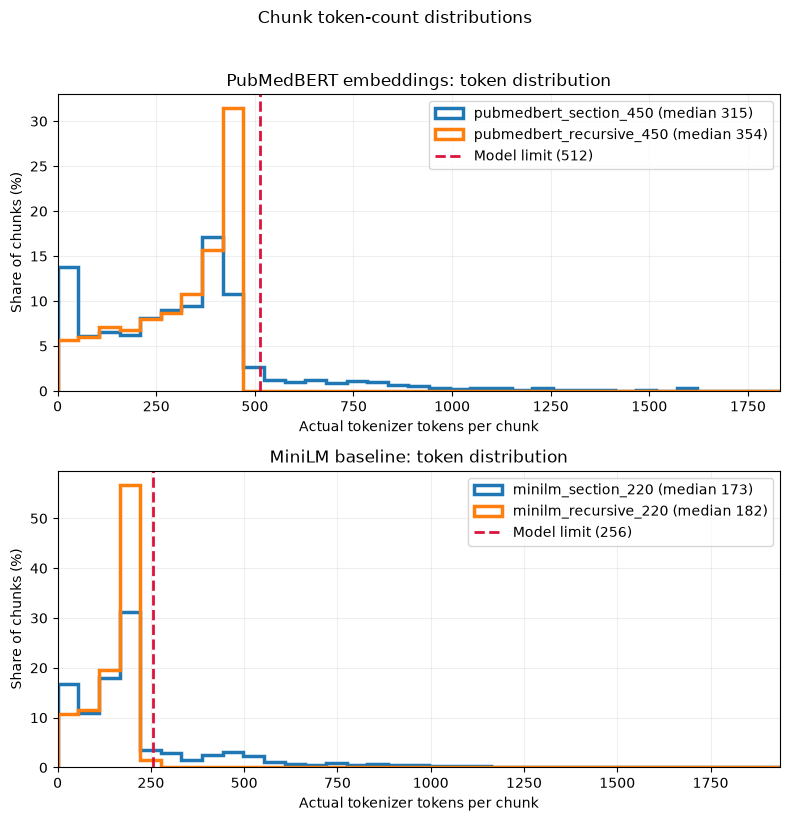

In [5]:
colors = {"section_aware": "#1f77b4", "recursive": "#ff7f0e"}

runs_by_model = {
    model_name: [run for run in CHUNKER_RUNS if run["model"] == model_name]
    for model_name in sorted({run["model"] for run in CHUNKER_RUNS})
}

run_stats = comparison_report.set_index("configuration")

fig, axes = plt.subplots(
    len(runs_by_model),
    1,
    figsize=(8, 4 * len(runs_by_model)),
    squeeze=False,
)

for row_index, (model_name, runs) in enumerate(runs_by_model.items()):
    axis = axes[row_index, 0]
    model_label = MODEL_LABELS.get(model_name, model_name)
    model_limit = int(run_stats.loc[runs[0]["name"], "model_limit"])
    max_seen = max((max(lengths_by_run[run["name"]], default=0) for run in runs), default=0)
    x_max = max(model_limit, max_seen, max(run["chunk_size"] for run in runs))
    bins = np.linspace(0, x_max * 1.05, 36)

    for run in runs:
        lengths = lengths_by_run[run["name"]]
        if lengths:
            weights = np.full(len(lengths), 100 / len(lengths))
            axis.hist(
                lengths,
                bins=bins,
                weights=weights,
                histtype="step",
                linewidth=2.5,
                color=colors[run["chunker"]],
                label=f"{run['name']} (median {int(np.median(lengths))})",
            )

    axis.axvline(
        model_limit,
        color="crimson",
        linestyle="--",
        linewidth=2,
        label=f"Model limit ({model_limit})",
    )

    axis.set(
        title=f"{model_label}: token distribution",
        xlabel="Actual tokenizer tokens per chunk",
        ylabel="Share of chunks (%)",
        xlim=(0, x_max * 1.05),
    )
    axis.grid(alpha=0.2)
    axis.legend()

fig.suptitle("Chunk token-count distributions", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

## 5. Inspect low and high token counts

Select any model/configuration to inspect its shortest and longest chunks.

In [6]:
INSPECTION_RUN = 'pubmedbert_section_450'
inspection_run = next(run for run in CHUNKER_RUNS if run['name'] == INSPECTION_RUN)
inspection_chunks = chunks_by_run[INSPECTION_RUN]
inspection_model = models[inspection_run['model']]

Short Chunks 

In [7]:
inspection_report_short = pd.DataFrame([{
    'tokens': token_count(chunk.page_content, inspection_model.tokenizer), 'chunk_id': chunk.metadata['chunk_id'],
    'title': chunk.metadata.get('title'), 'page': chunk.metadata.get('page_number'),
    'section': chunk.metadata.get('section_title'), 'preview': chunk.page_content[:250].replace('\\n', ' '),
} for chunk in inspection_chunks]).sort_values('tokens', ascending=True)
display(inspection_report_short.head(20))
example = inspection_chunks[inspection_report_short.index[0]]
print(example.metadata)
print(example.page_content)

,tokens,chunk_id,title,page,section,preview
106,3,eef14589e173df76:4:1,"WHO Drug Information 2026, vol. 40, 1 [full is...",4.0,ICDRA,ICH
784,3,a4bad53494577b52:8:1,"WHO Drug Information 2026, vol. 40, 2 [full is...",8.0,REQUIRED,COST
1867,3,a4bad53494577b52:442:1,"WHO Drug Information 2026, vol. 40, 2 [full is...",442.0,VLDSDGSFFL YSKLTVDKSR WQQGNVFSCS VMHEALHNHY TQ...,K
1386,3,a4bad53494577b52:267:3,"WHO Drug Information 2026, vol. 40, 2 [full is...",267.0,PVLDSDGSFF LYSKLTVDKS RWQQGNVFSC SVMHEALHNH YT...,GK
1488,4,a4bad53494577b52:304:3,"WHO Drug Information 2026, vol. 40, 2 [full is...",304.0,PPVLDSDGSF FLYSKLTVDK SRWQQGNVFS CSVMHEALHN HY...,PGK
1077,5,a4bad53494577b52:164:1,"WHO Drug Information 2026, vol. 40, 2 [full is...",164.0,L01ED06,ensartanib
1098,5,a4bad53494577b52:165:0,"WHO Drug Information 2026, vol. 40, 2 [full is...",165.0,S01XA37,recoflavone
1090,5,a4bad53494577b52:164:14,"WHO Drug Information 2026, vol. 40, 2 [full is...",164.0,L04AG21,ianalumab
1099,5,a4bad53494577b52:165:1,"WHO Drug Information 2026, vol. 40, 2 [full is...",165.0,S03AA09,lomefloxacin
1064,5,a4bad53494577b52:163:2,"WHO Drug Information 2026, vol. 40, 2 [full is...",163.0,B01AC29,becondogrel


{'document_id': 'eef14589e173df76', 'source': 'https://iris.who.int/handle/10665/385136', 'source_type': 'pdf', 'source_name': 'WHO IRIS Publications', 'title': 'WHO Drug Information 2026, vol. 40, 1 [full issue]', 'description': 'Ensuring consistent identification and quality assurance of pharmaceutical substances is a fundamental component of global medicines regulation and patient safety. This issue of WHO Drug Information, a quarterly publication of the World Health Organization, presents a collection of technical and regulatory materials, including consultation documents and the latest Recommended International Nonproprietary Names (INN) for pharmaceutical substances.\n\nIt outlines draft monographs for dapsone and dapsone tablets intended for inclusion in The International Pharmacopoeia, detailing specifications for identity, purity, assay methods, and impurity control using standardized analytical techniques such as chromatography and spectrophotometry. The publication further c

Long Chunks

In [8]:
inspection_report_long = pd.DataFrame([{
    'tokens': token_count(chunk.page_content, inspection_model.tokenizer),
    'title': chunk.metadata.get('title'), 'page': chunk.metadata.get('page_number'),
    'preview': chunk.page_content[:250].replace('\\n', ' '),
} for chunk in inspection_chunks]).sort_values('tokens', ascending=False)
display(inspection_report_long.head(10))
example = inspection_chunks[inspection_report_long.index[0]]
print(example.metadata)
print(example.page_content)

,tokens,title,page,preview
1297,1744,"WHO Drug Information 2026, vol. 40, 2 [full is...",236.0,elzegurán\nARN guía (gRNA) dirigido a un sitio...
1198,1643,"WHO Drug Information 2026, vol. 40, 2 [full is...",197.0,birfutamig\ninmunoglobulina (H-gamma1_L-kappa)...
1296,1611,"WHO Drug Information 2026, vol. 40, 2 [full is...",235.0,elzéguran\nARN guide (gRNA) ciblant un site do...
1187,1606,"WHO Drug Information 2026, vol. 40, 2 [full is...",192.0,besnotamig\ninmunoglobulina (H-gamma4_L-kappa)...
1295,1587,"WHO Drug Information 2026, vol. 40, 2 [full is...",234.0,elzeguran\nguide RNA (gRNA) targeting a splice...
1185,1586,"WHO Drug Information 2026, vol. 40, 2 [full is...",191.0,besnotamig\nimmunoglobuline (H-gamma4_L-kappa)...
742,1577,"WHO Drug Information 2026, vol. 40, 1 [full is...",269.0,todo-P-ambo-2'-O-metil-P-tioadenilil-(3'→5')-2...
252,1577,"WHO Drug Information 2026, vol. 40, 1 [full is...",67.0,immunoglobulin (H-gamma1_L-kappa)_(G1(VH-CH1-h...
404,1570,"WHO Drug Information 2026, vol. 40, 1 [full is...",129.0,lumivatamig\ninmunoglobulina (H-gamma1_L-kappa...
403,1552,"WHO Drug Information 2026, vol. 40, 1 [full is...",128.0,lumivatamig\nimmunoglobuline (H-gamma1_L-kappa...


{'document_id': 'a4bad53494577b52', 'source': 'https://iris.who.int/handle/10665/386676', 'source_type': 'pdf', 'source_name': 'WHO IRIS Publications', 'title': 'WHO Drug Information 2026, vol. 40, 2 [full issue]', 'description': 'This issue of WHO Drug Information presents technical and regulatory information on medicines development, quality, safety and classification. It includes a methodological pilot study on the use of an adapted GRADE Evidence-to-Decision framework to support prioritization of PD-1 and PD-L1 immune checkpoint inhibitors for possible inclusion in the WHO Model List of Essential Medicines for adults with solid tumours in the palliative first-line setting. The study examines clinical benefits and harms alongside certainty of evidence, patient values, costs, cost-effectiveness, equity, acceptability, feasibility and availability.\n\nThe issue also publishes consultation documents providing updated guidance on bioequivalence for immediate-release oral dosage forms, a

## 6. Example Retrieval comparison

Add domain questions and expected terms. Embed the question query every run, retrieve top-k chunks, and calculate a simple hit@k

In [9]:
import json
from pathlib import Path

EVALUATION_QUERIES = json.loads(Path("eval_questions.json").read_text(encoding="utf-8"))

print(f"Loaded {len(EVALUATION_QUERIES)} evaluation queries")

Loaded 50 evaluation queries


In [10]:
from app.embeddings import embed_texts

RUN_RETRIEVAL_COMPARISON = True
TOP_K = 5

if RUN_RETRIEVAL_COMPARISON:
    if not EVALUATION_QUERIES:
        raise ValueError('Add at least one evaluation query before enabling retrieval comparison.')
    retrieval_rows = []
    runs_by_model = {
        model_name: [run for run in CHUNKER_RUNS if run['model'] == model_name]
        for model_name in sorted({run['model'] for run in CHUNKER_RUNS})
    }
    for model_name, runs in runs_by_model.items():
        model = models[model_name]
        model_label = MODEL_LABELS.get(model_name, model_name)
        query_vectors = embed_texts([item['query'] for item in EVALUATION_QUERIES], model)
        for run in runs:
            chunks = chunks_by_run[run['name']]
            chunk_vectors = embed_texts([chunk.page_content for chunk in chunks], model)
            for query_item, query_vector in zip(EVALUATION_QUERIES, query_vectors):
                top_indices = np.argsort(chunk_vectors @ query_vector)[-TOP_K:][::-1]
                top_chunks = [chunks[index] for index in top_indices]
                expected = [term.lower() for term in query_item['expected_terms']]
                hit = any(any(term in chunk.page_content.lower() for term in expected) for chunk in top_chunks)
                retrieval_rows.append({'model': model_label, 'configuration': run['name'], 'query': query_item['query'], f'hit@{TOP_K}': hit, 'top_chunk_preview': top_chunks[0].page_content[:180].replace('\\n', ' ')})
    retrieval_report = pd.DataFrame(retrieval_rows)
    summary = retrieval_report.groupby(['model', 'configuration'])[f'hit@{TOP_K}'].mean().rename(f'mean_hit@{TOP_K}').reset_index()
    display(summary.sort_values(f'mean_hit@{TOP_K}', ascending=False))
    display(retrieval_report)
else:
    print('Set RUN_RETRIEVAL_COMPARISON = True after adding labelled queries to run this section.')

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/65 [00:00<?, ?it/s]

Batches:   0%|          | 0/71 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/154 [00:00<?, ?it/s]

,model,configuration,mean_hit@5
1,MiniLM baseline,minilm_section_220,0.94
0,MiniLM baseline,minilm_recursive_220,0.90
3,PubMedBERT embeddings,pubmedbert_section_450,0.90
2,PubMedBERT embeddings,pubmedbert_recursive_450,0.86


,model,configuration,query,hit@5,top_chunk_preview
0,PubMedBERT embeddings,pubmedbert_section_450,How many raw signals were scanned and triangul...,True,Signals designated as “Not yet diagnosed” refe...
1,PubMedBERT embeddings,pubmedbert_section_450,How many signals met assessment thresholds and...,True,Signals designated as “Not yet diagnosed” refe...
2,PubMedBERT embeddings,pubmedbert_section_450,How many unique signals were identified out of...,True,Signals designated as “Not yet diagnosed” refe...
3,PubMedBERT embeddings,pubmedbert_section_450,How many signals were escalated for operationa...,True,Signals designated as “Not yet diagnosed” refe...
4,PubMedBERT embeddings,pubmedbert_section_450,How many confirmed cases and deaths were repor...,True,"Selected Weekly Events, 20 July – 26 July 2026..."
...,...,...,...,...,...
195,MiniLM baseline,minilm_recursive_220,How many pregnancies occurred among adolescent...,True,"Key facts\nAs of 2019, adolescents aged 15–19 ..."
196,MiniLM baseline,minilm_recursive_220,By what year will 1 in 6 people in the world b...,True,Overview\nPeople worldwide are living longer. ...
197,MiniLM baseline,minilm_recursive_220,How many deaths were caused by alcohol consump...,True,Overview\nAlcohol and alcoholic beverages cont...
198,MiniLM baseline,minilm_recursive_220,What percentage of global cancer deaths in 201...,True,Health risks of alcohol use\nAlcohol consumpti...
